# **Tabular Kaggle Project**

- Project link- https://www.kaggle.com/competitions/widsdatathon2024-challenge1/rules

- Challenge- The goal of this project is to build a machine learning model that predicts whether a patient will receive a metastatic breast cancer diagnosis within 90 days of screening, using real-world healthcare data. We are tasked with developing predictive models to determine the likelihood of a patient being diagnosed with metastatic cancer shortly after screening.

- Brief Description of the Data- The dataset contains tabular healthcare data including patient demographics, medical history, screening information, and treatment-related variables. It also includes features related to healthcare access and socioeconomic factors.

###**Data Loading and Initial Look**

In [5]:
#unzipping zip files

import zipfile

with zipfile.ZipFile('training.csv.zip', 'r') as z:
    z.extractall('.')

with zipfile.ZipFile('test.csv.zip', 'r') as z:
    z.extractall('.')

In [6]:
#loading data

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

train = pd.read_csv('training.csv')
test = pd.read_csv('test.csv')

print("Training shape:", train.shape)
print("Test shape:", test.shape)
train.head()

Training shape: (12906, 83)
Test shape: (5792, 82)


,patient_id,patient_race,payer_type,patient_state,patient_zip3,patient_age,patient_gender,bmi,breast_cancer_diagnosis_code,breast_cancer_diagnosis_desc,...,disabled,poverty,limited_english,commute_time,health_uninsured,veteran,Ozone,PM25,N02,DiagPeriodL90D
0,475714,NaN,MEDICAID,CA,924,84,F,NaN,C50919,Malignant neoplasm of unsp site of unspecified...,...,12.871429,22.542857,10.100000,27.814286,11.200000,3.500000,52.237210,8.650555,18.606528,1
1,349367,White,COMMERCIAL,CA,928,62,F,28.49,C50411,Malig neoplm of upper-outer quadrant of right ...,...,8.957576,10.109091,8.057576,30.606061,7.018182,4.103030,42.301121,8.487175,20.113179,1
2,138632,White,COMMERCIAL,TX,760,43,F,38.09,C50112,Malignant neoplasm of central portion of left ...,...,11.253333,9.663333,3.356667,31.394915,15.066667,7.446667,40.108207,7.642753,14.839351,1
3,617843,White,COMMERCIAL,CA,926,45,F,NaN,C50212,Malig neoplasm of upper-inner quadrant of left...,...,8.845238,8.688095,5.280952,27.561905,4.404762,4.809524,42.070075,7.229393,15.894123,0
4,817482,NaN,COMMERCIAL,ID,836,55,F,NaN,1749,"Malignant neoplasm of breast (female), unspeci...",...,15.276000,11.224000,1.946000,26.170213,12.088000,13.106000,41.356058,4.110749,11.722197,0


In [10]:
#Rows and features
print("Rows:", train.shape[0])
print("Features:", train.shape[1])

#Missing values
print(train.isnull().sum())

#Feature table
train.describe()

train.dtypes

Rows: 12906
Features: 83
patient_id           0
patient_race      6385
payer_type        1803
patient_state       51
patient_zip3         0
                  ... 
veteran              1
Ozone               29
PM25                29
N02                 29
DiagPeriodL90D       0
Length: 83, dtype: int64


patient_id          int64
patient_race       object
payer_type         object
patient_state      object
patient_zip3        int64
                   ...   
veteran           float64
Ozone             float64
PM25              float64
N02               float64
DiagPeriodL90D      int64
Length: 83, dtype: object

In [11]:
# Full feature summary table
summary = pd.DataFrame({
    'dtype': train.dtypes,
    'missing_values': train.isnull().sum(),
    'missing_pct': (train.isnull().sum() / len(train) * 100).round(2),
    'nunique': train.nunique()
})

# min/max for numerical columns
summary['min'] = train.min(numeric_only=True)
summary['max'] = train.max(numeric_only=True)

print(summary.to_string())

                                         dtype  missing_values  missing_pct  nunique            min           max
patient_id                               int64               0         0.00    12906  100063.000000  9.998960e+05
patient_race                            object            6385        49.47        5            NaN           NaN
payer_type                              object            1803        13.97        3            NaN           NaN
patient_state                           object              51         0.40       50            NaN           NaN
patient_zip3                             int64               0         0.00      739     101.000000  9.990000e+02
patient_age                              int64               0         0.00       67      18.000000  9.100000e+01
patient_gender                          object               0         0.00        1            NaN           NaN
bmi                                    float64            8965        69.46     1342    

In [12]:
# Class imbalance 
print(train['DiagPeriodL90D'].value_counts())
print(train['DiagPeriodL90D'].value_counts(normalize=True))

print(train['DiagPeriodL90D'].unique())

DiagPeriodL90D
1    8060
0    4846
Name: count, dtype: int64
DiagPeriodL90D
1    0.624516
0    0.375484
Name: proportion, dtype: float64
[1 0]


In [13]:
# Outliers- An outlier is defined as any value more than 1.5x the IQR below Q1 or above Q3
numerical = train.select_dtypes(include=np.number).columns.tolist()

for col in numerical:
    Q1 = train[col].quantile(0.25)
    Q3 = train[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = train[(train[col] < Q1 - 1.5*IQR) | (train[col] > Q3 + 1.5*IQR)]
    print(f"{col}: {len(outliers)} outliers")

patient_id: 0 outliers
patient_zip3: 0 outliers
patient_age: 44 outliers
bmi: 2 outliers
population: 192 outliers
density: 1092 outliers
age_median: 62 outliers
age_under_10: 171 outliers
age_10_to_19: 254 outliers
age_20s: 391 outliers
age_30s: 375 outliers
age_40s: 141 outliers
age_50s: 131 outliers
age_60s: 222 outliers
age_70s: 316 outliers
age_over_80: 470 outliers
male: 549 outliers
female: 549 outliers
married: 153 outliers
divorced: 26 outliers
never_married: 26 outliers
widowed: 319 outliers
family_size: 142 outliers
family_dual_income: 94 outliers
income_household_median: 703 outliers
income_household_under_5: 299 outliers
income_household_5_to_10: 555 outliers
income_household_10_to_15: 301 outliers
income_household_15_to_20: 441 outliers
income_household_20_to_25: 240 outliers
income_household_25_to_35: 87 outliers
income_household_35_to_50: 114 outliers
income_household_50_to_75: 455 outliers
income_household_75_to_100: 60 outliers
income_household_100_to_150: 22 outliers


###**Data Visualization**

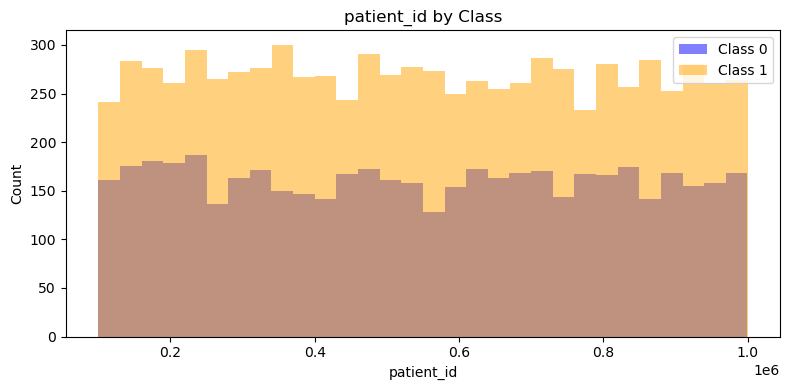

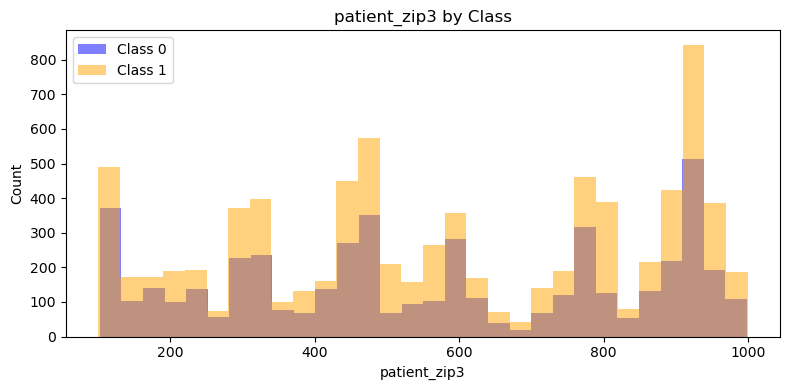

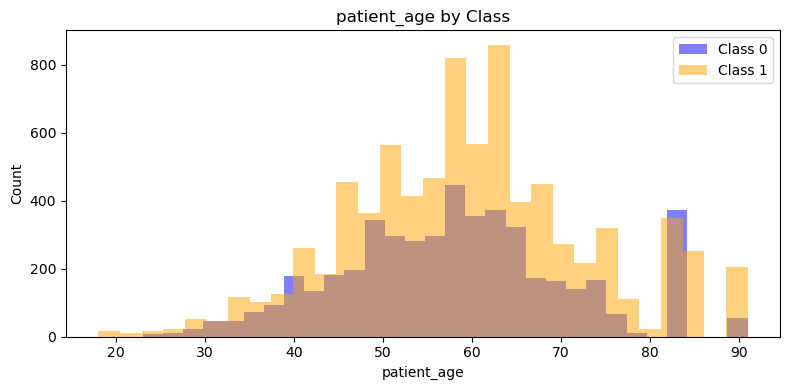

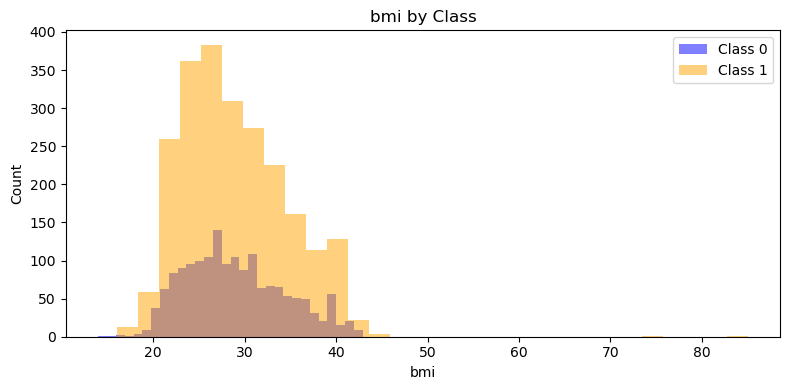

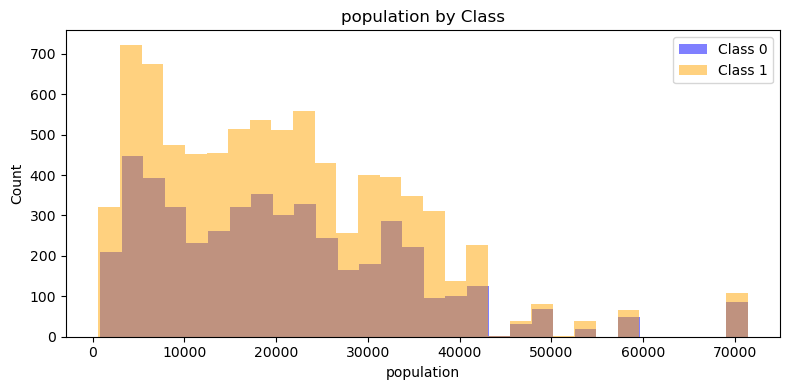

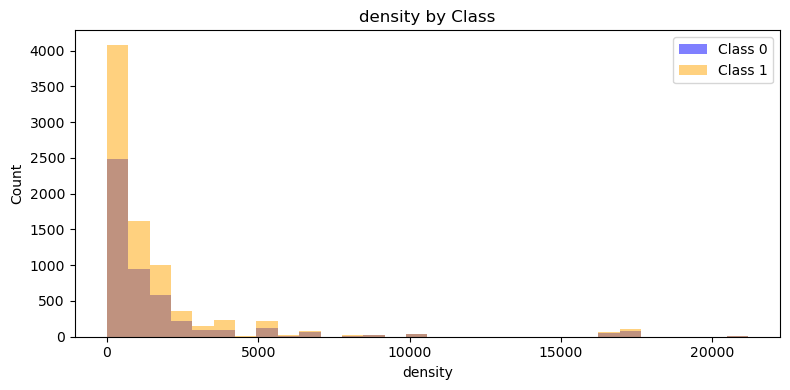

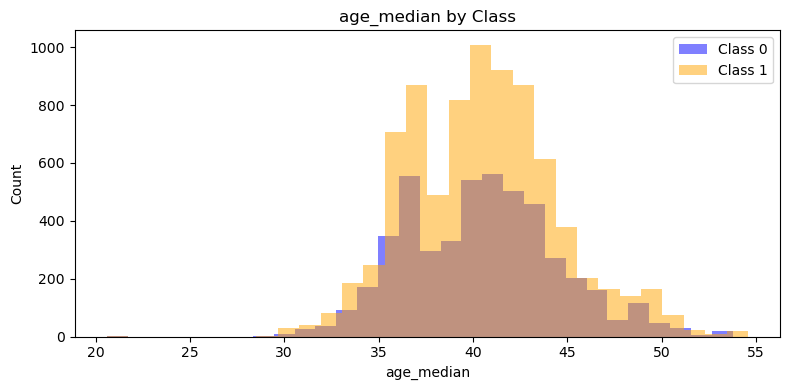

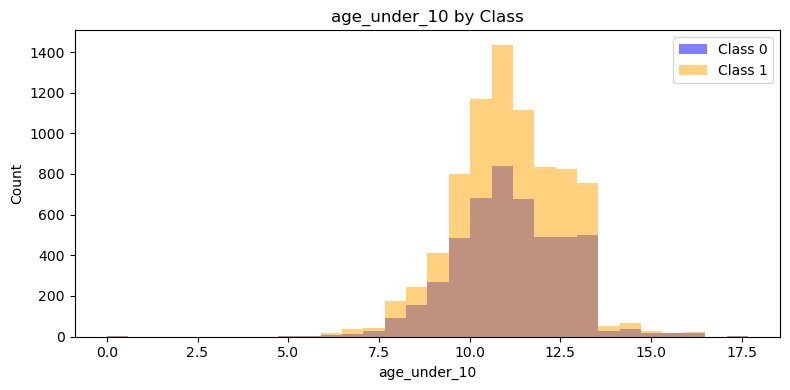

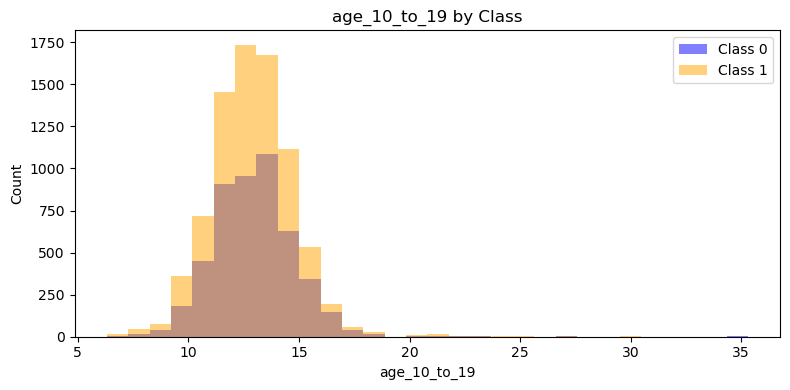

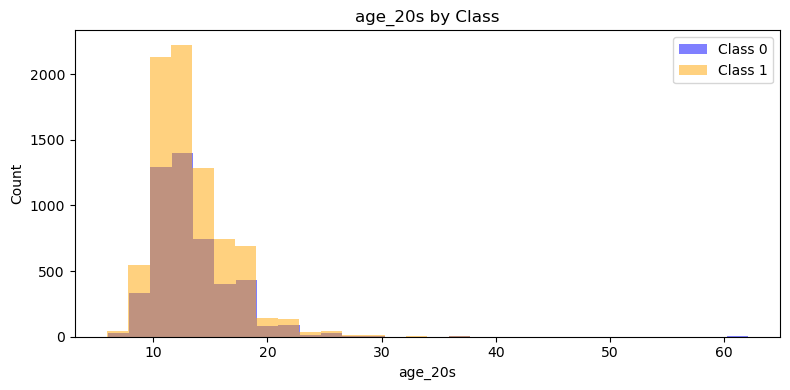

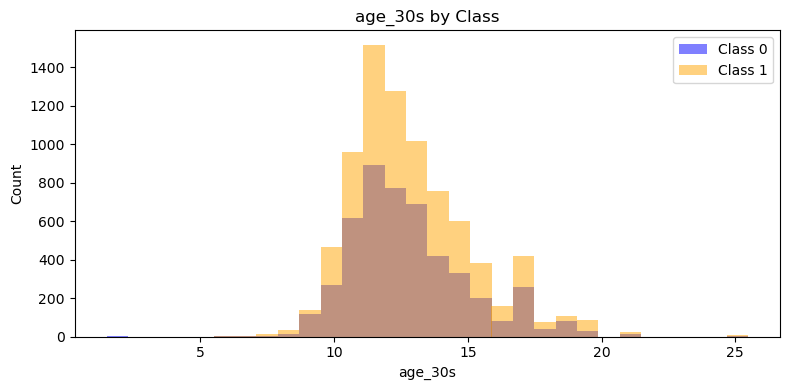

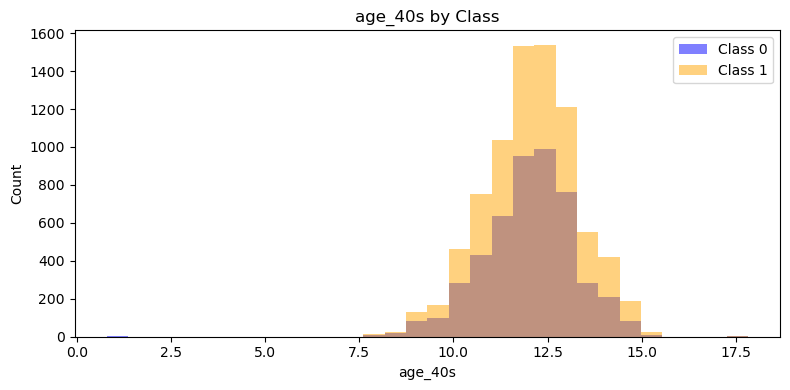

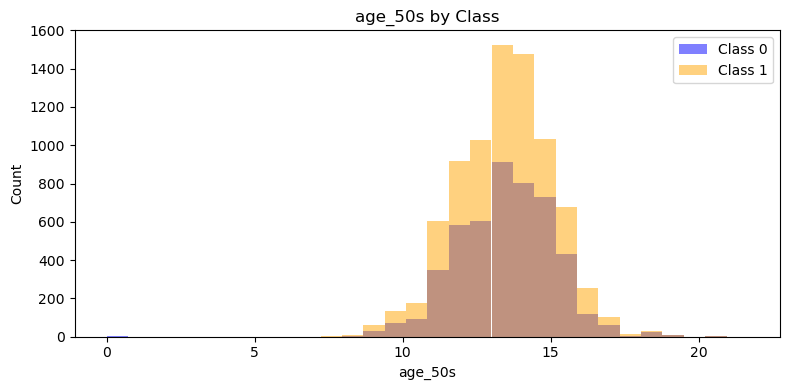

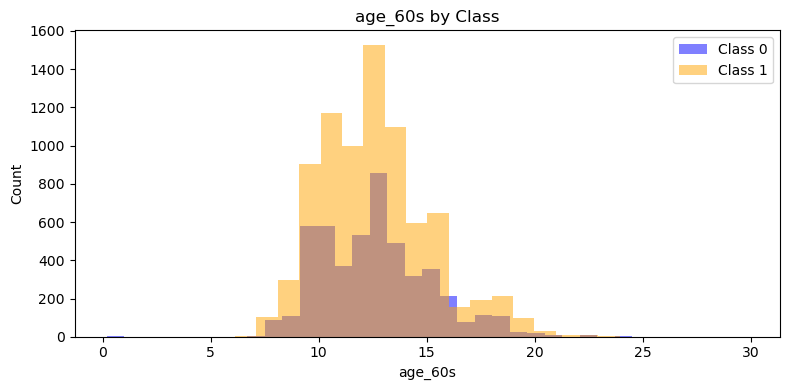

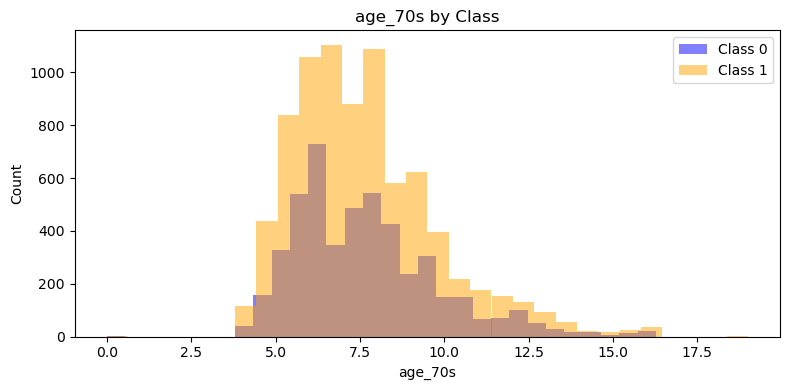

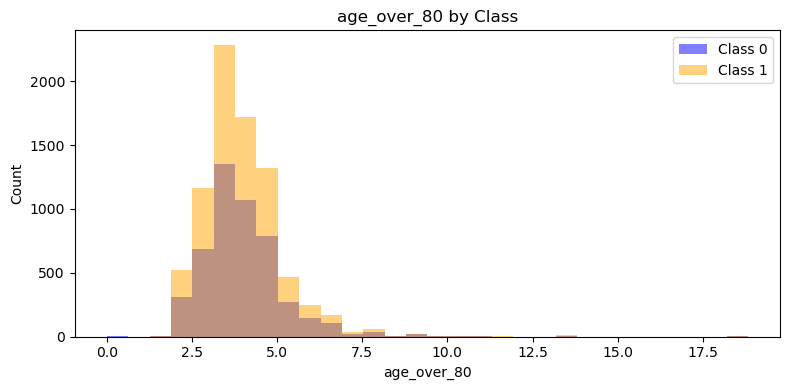

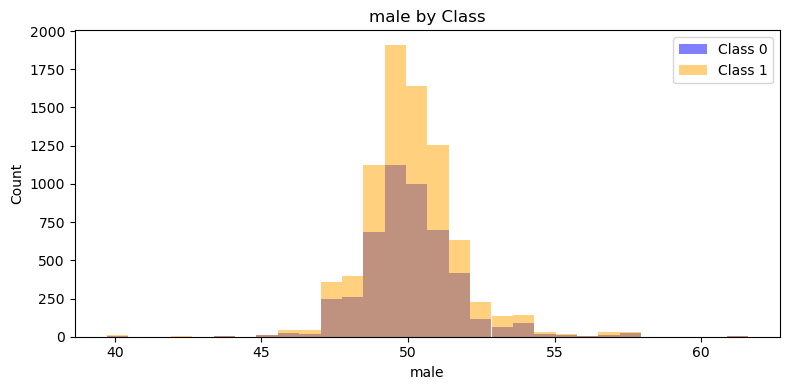

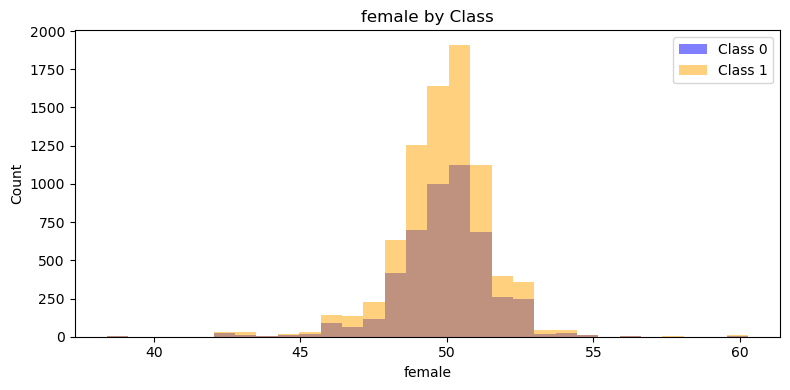

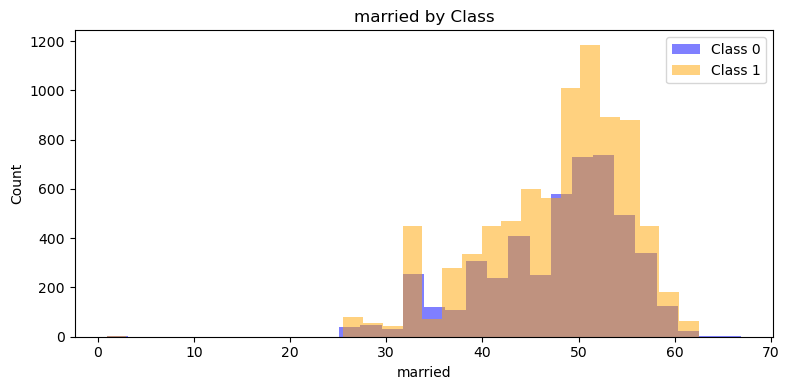

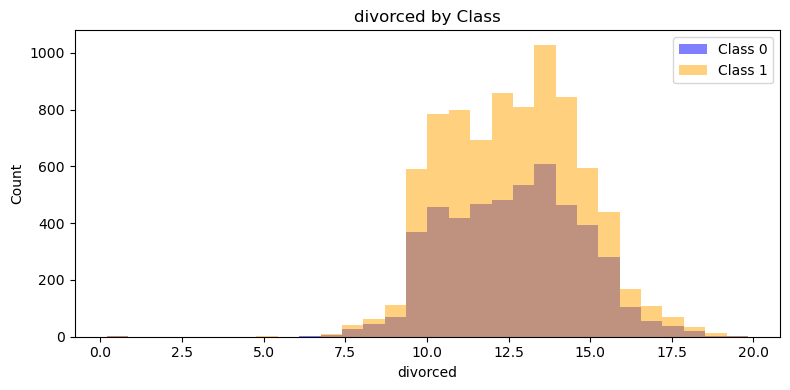

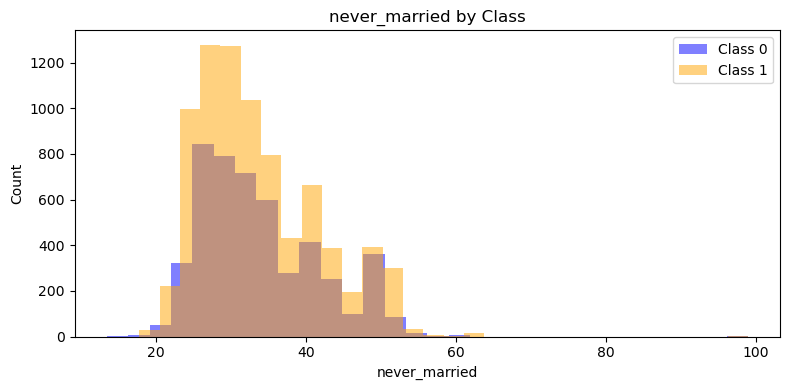

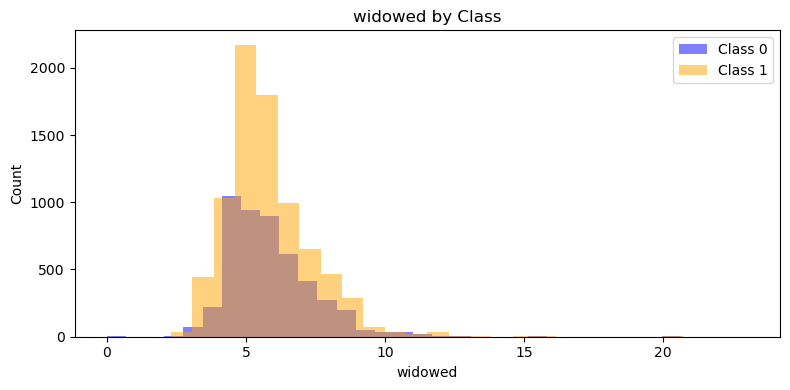

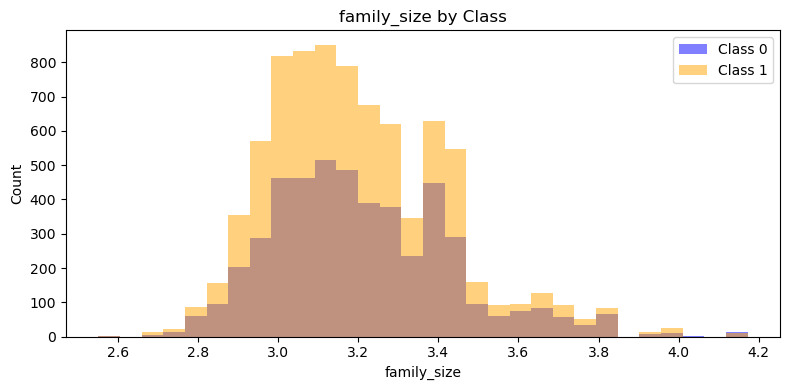

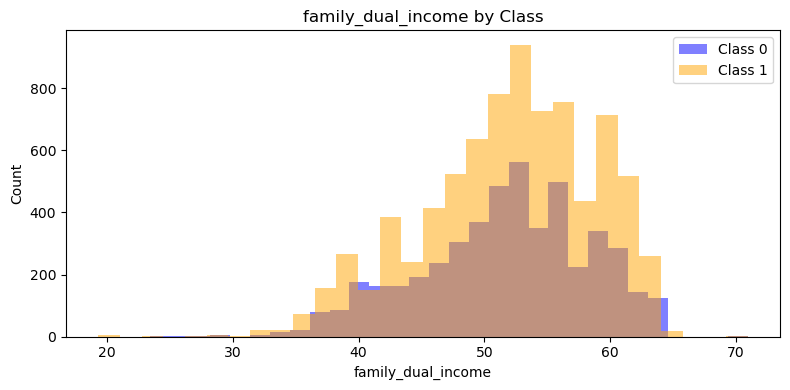

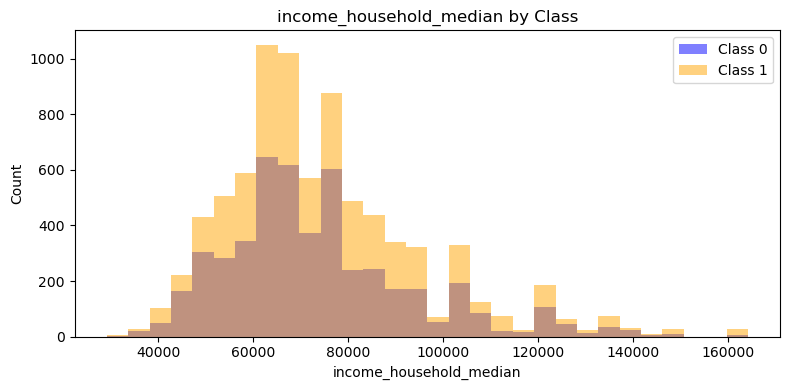

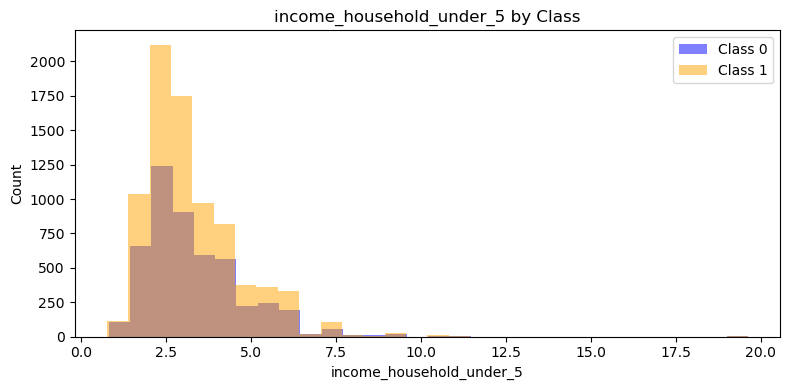

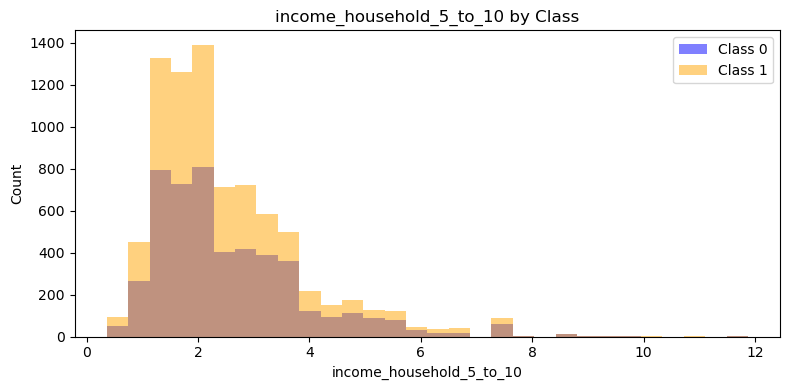

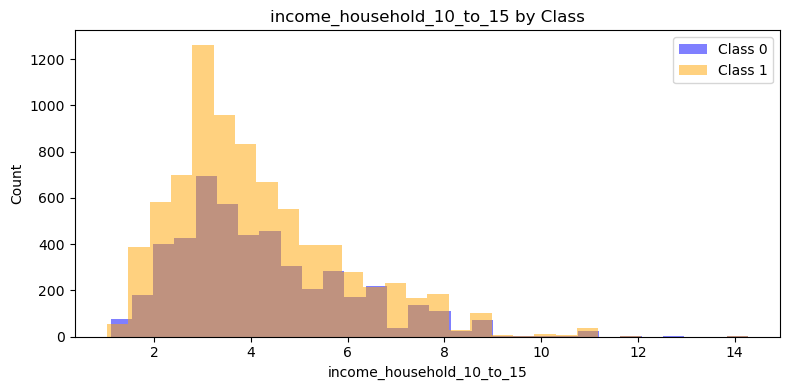

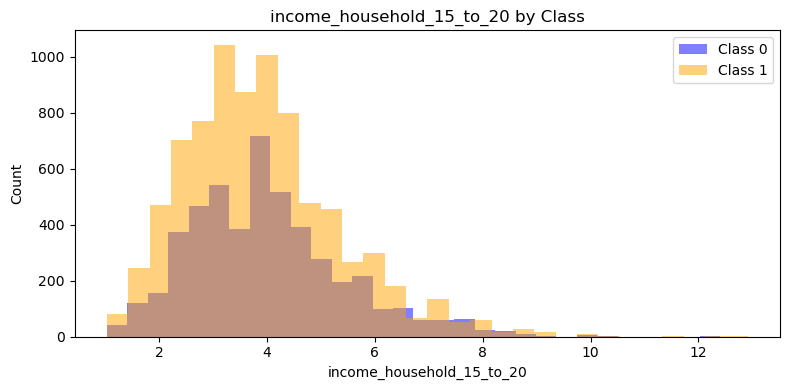

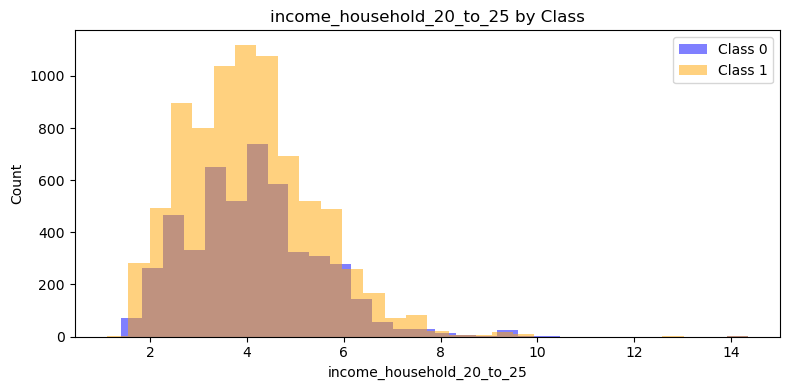

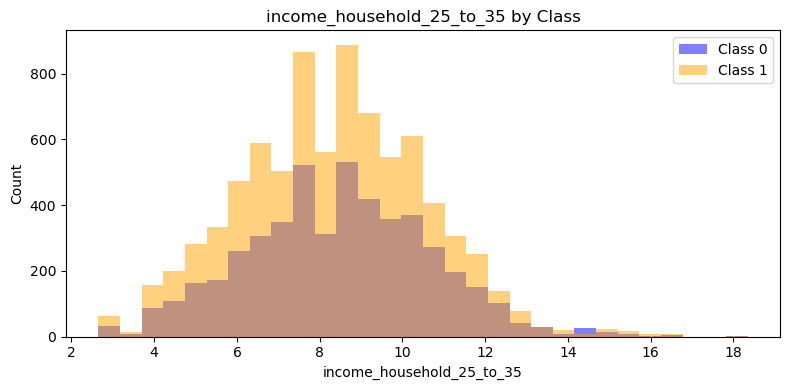

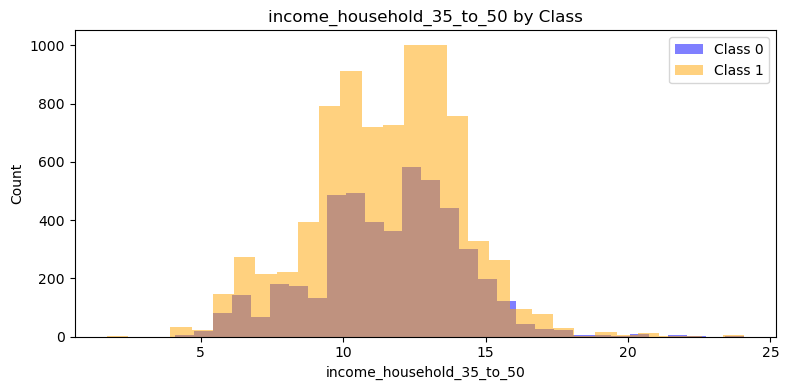

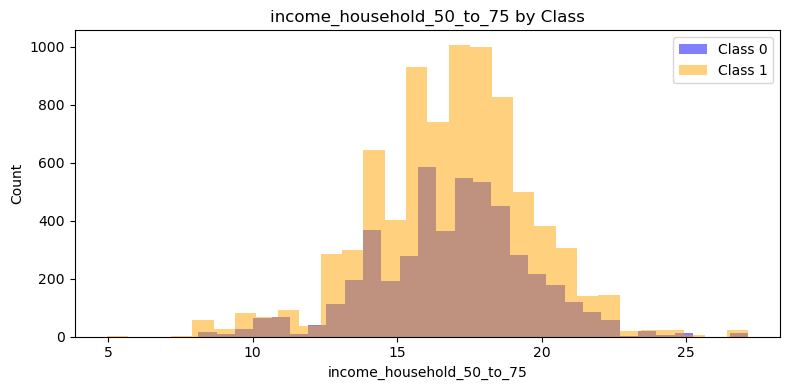

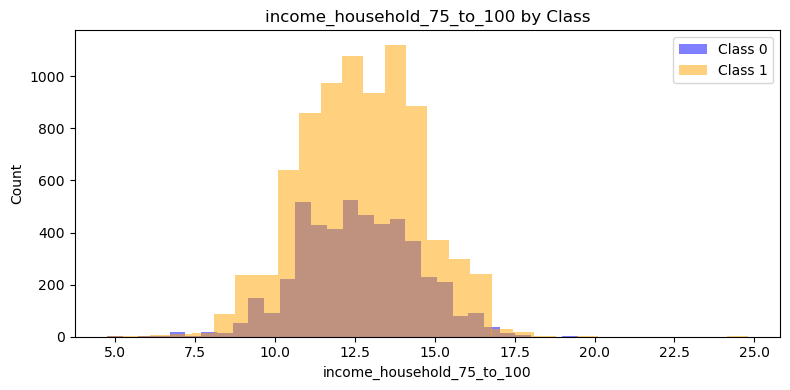

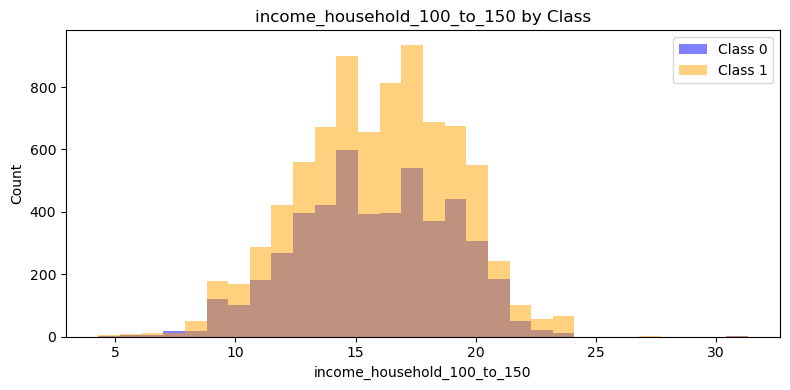

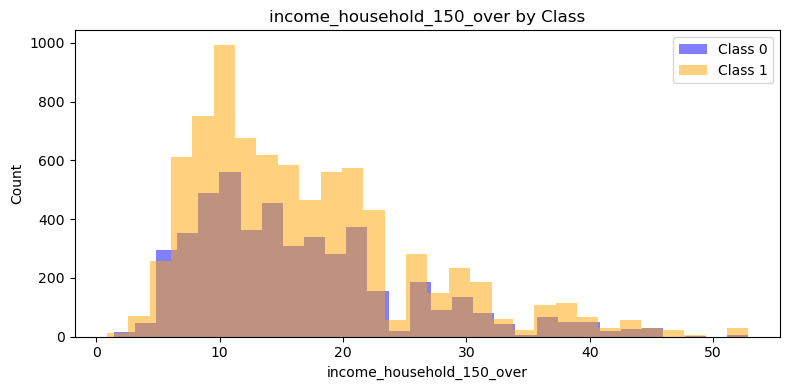

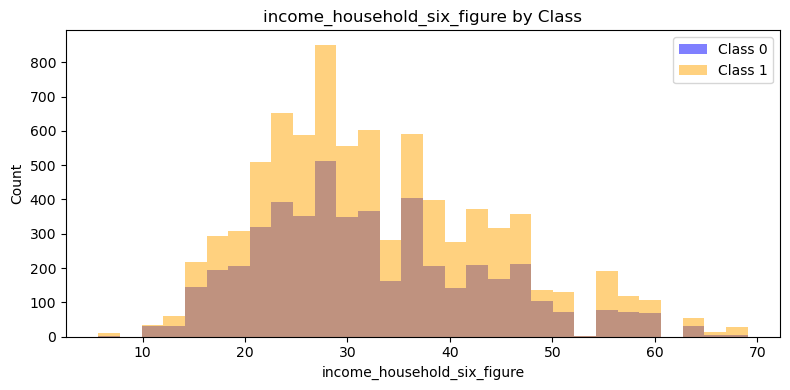

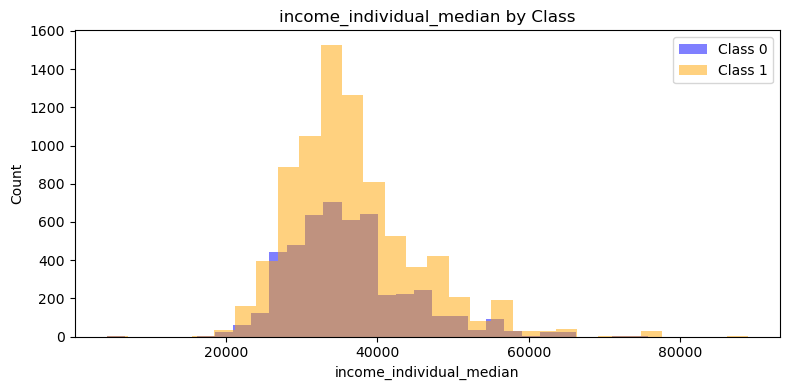

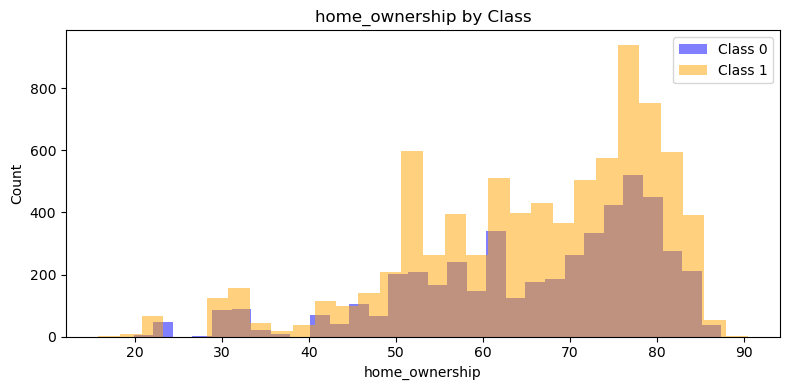

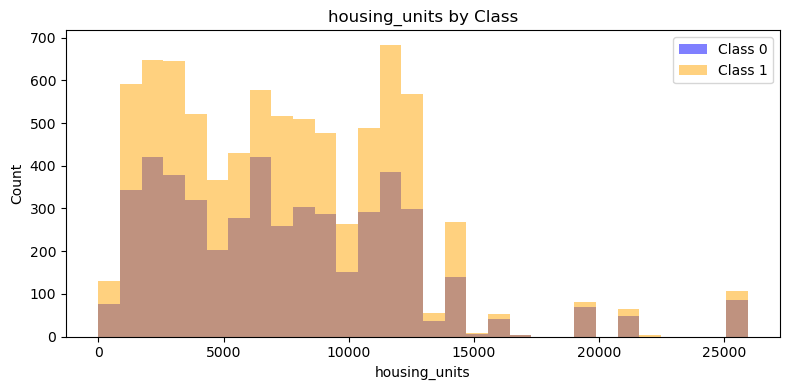

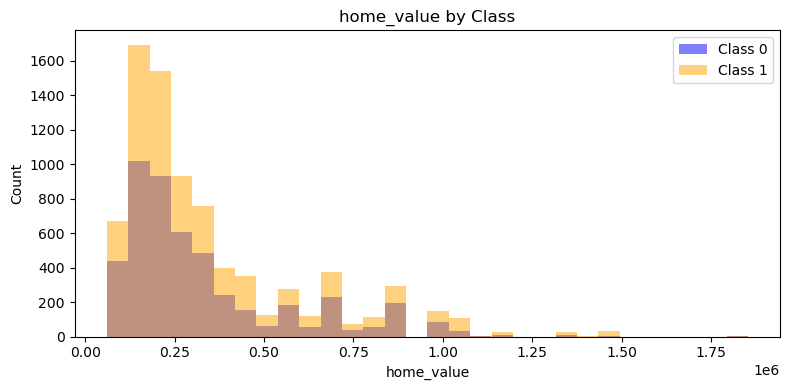

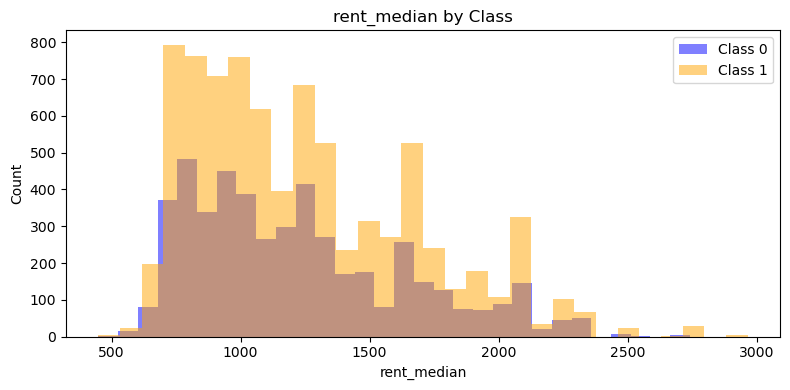

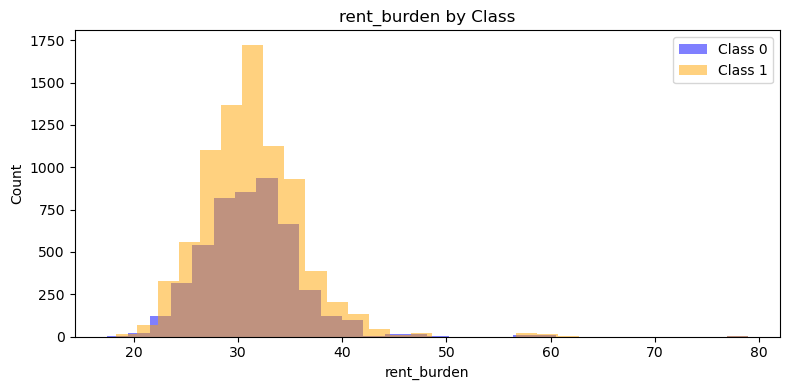

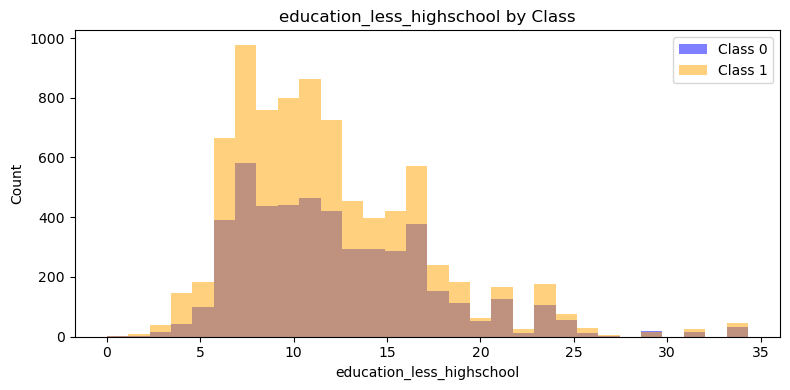

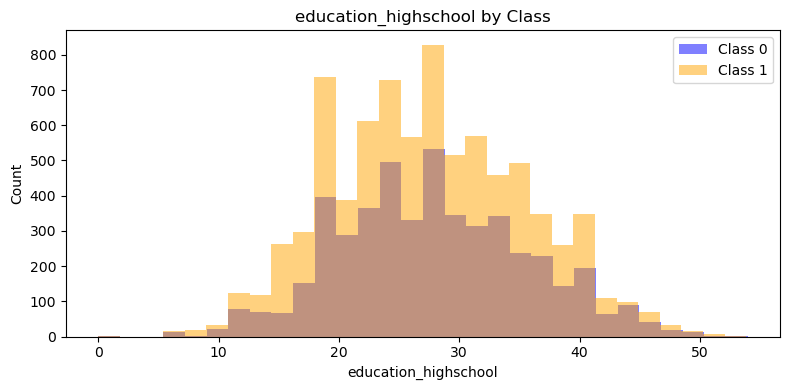

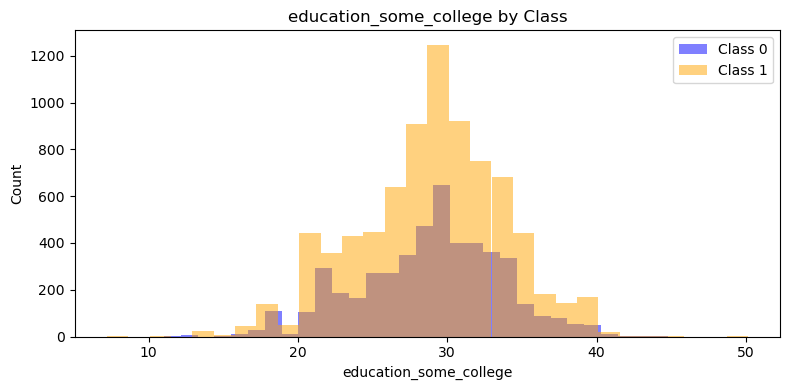

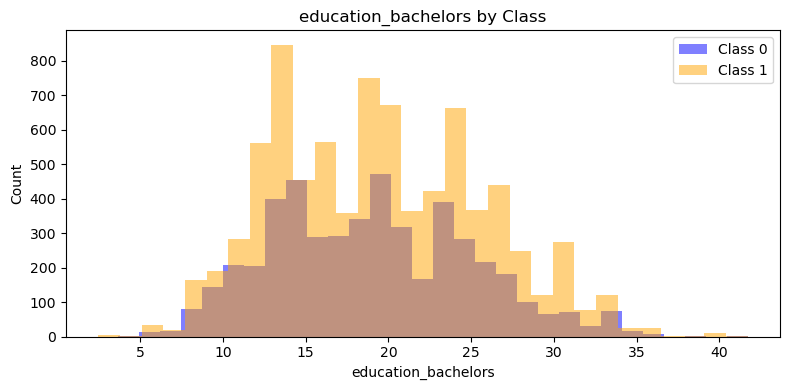

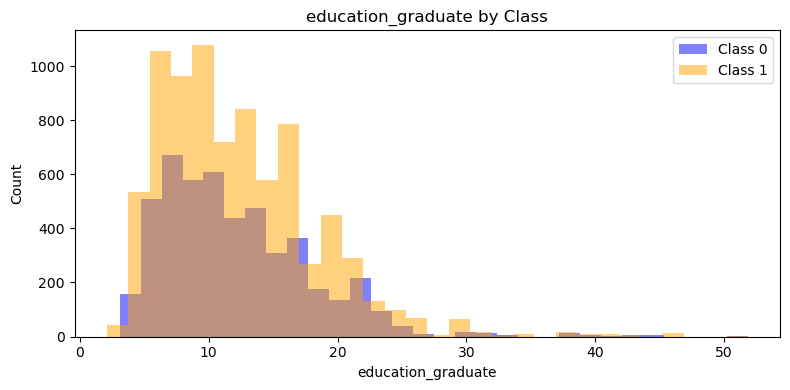

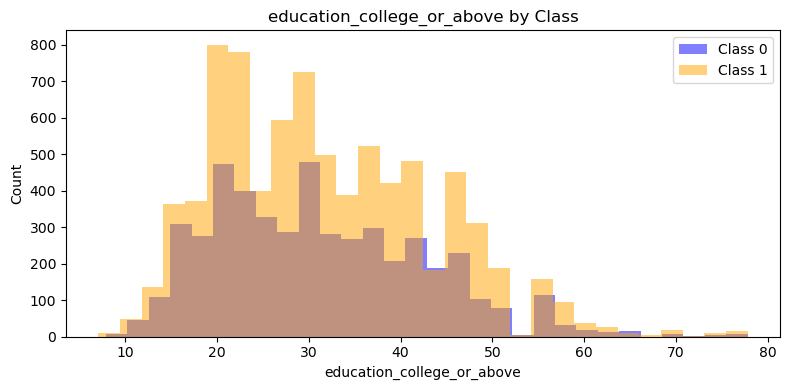

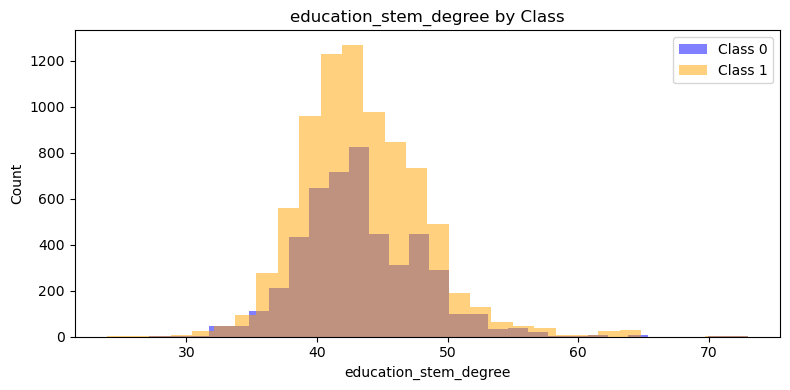

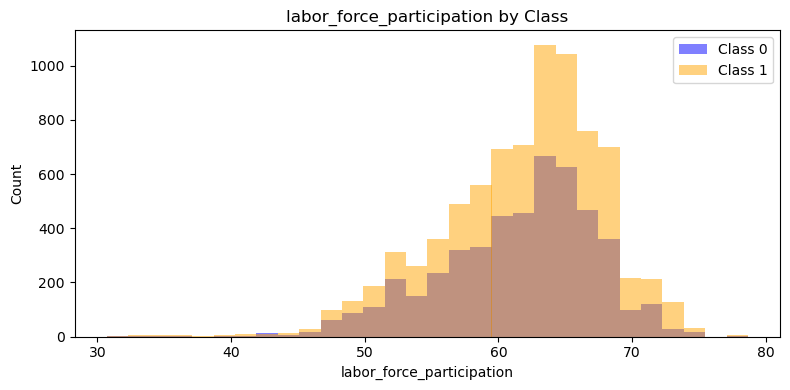

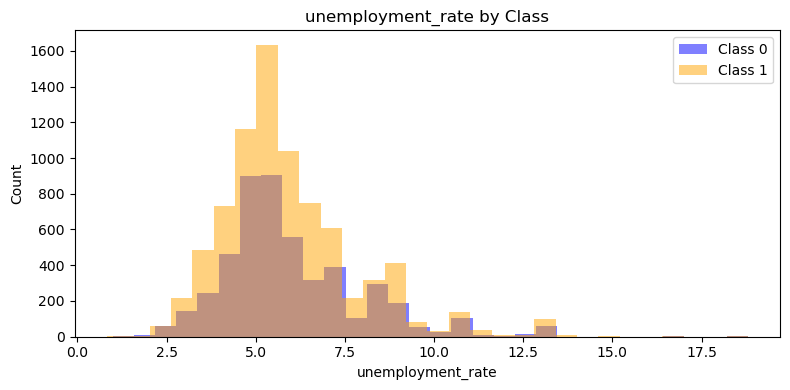

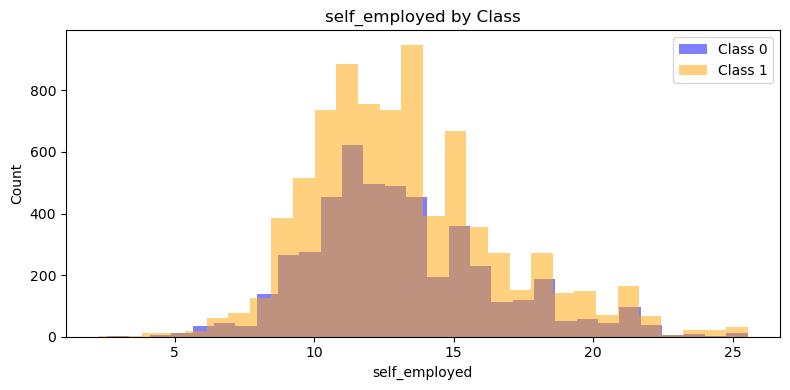

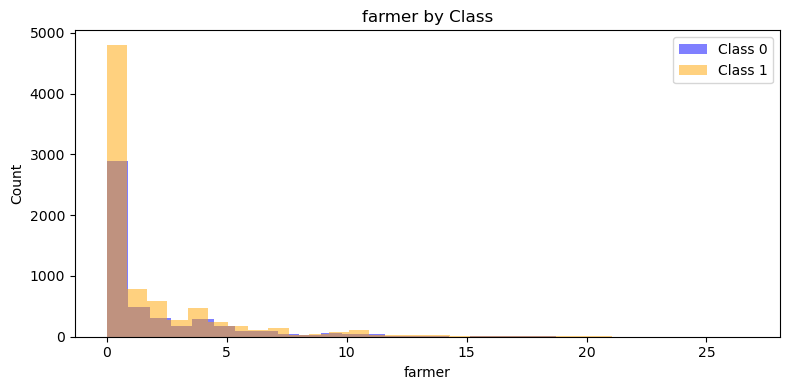

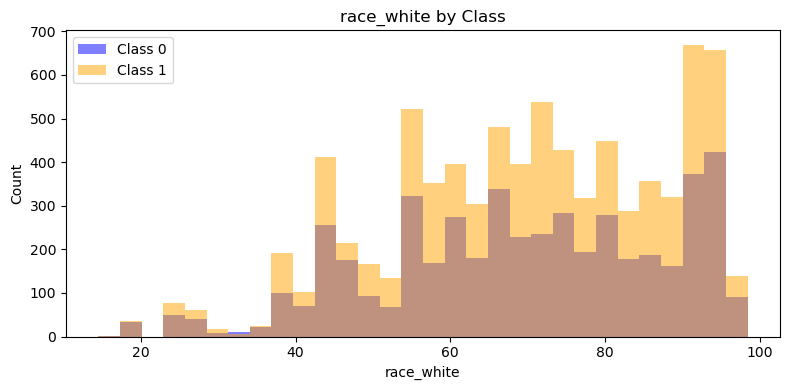

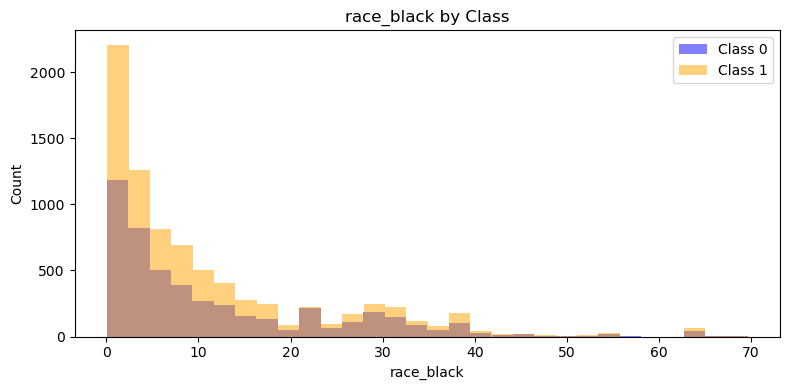

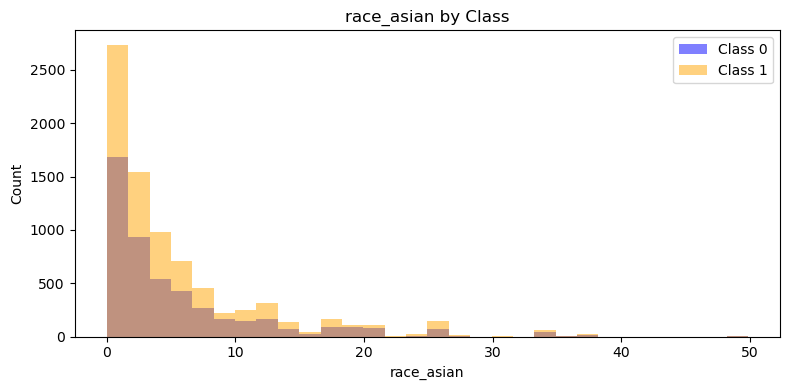

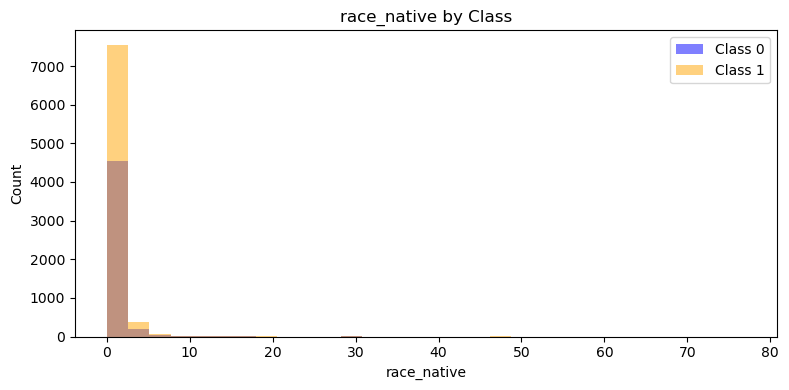

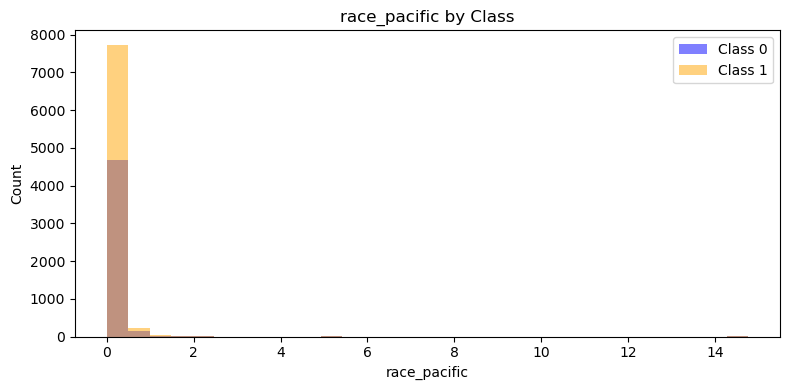

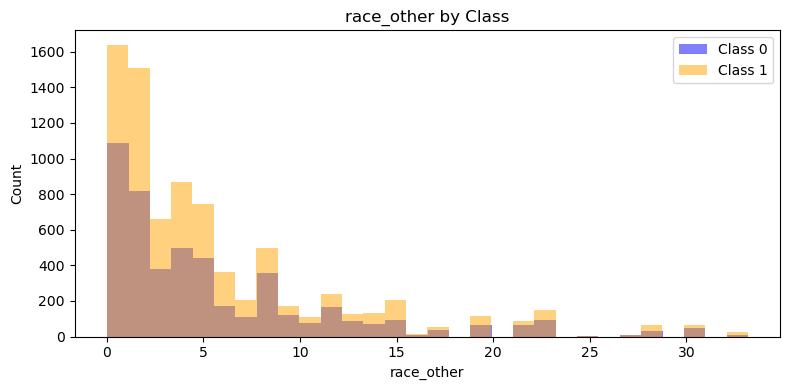

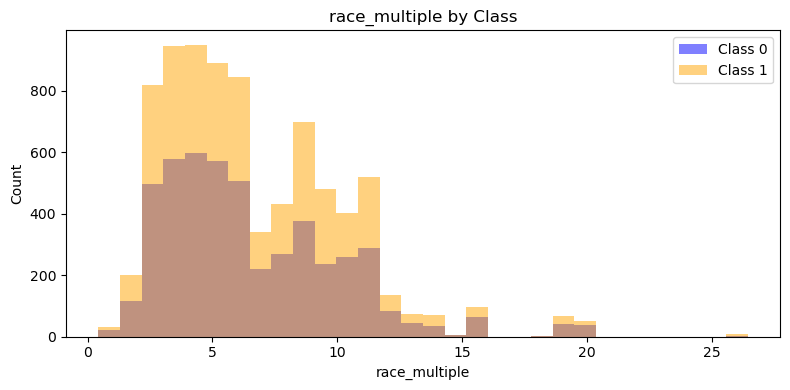

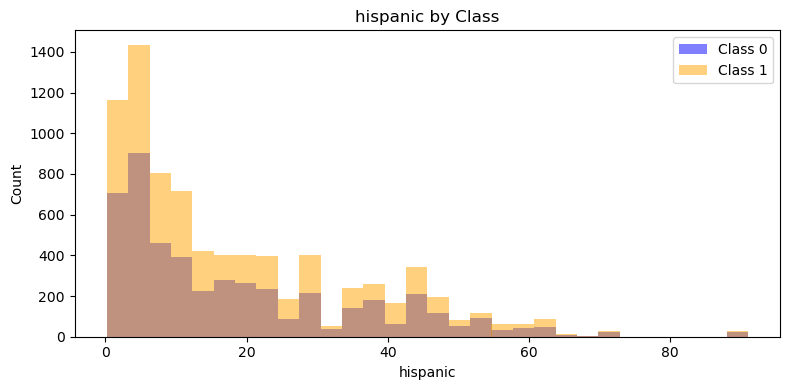

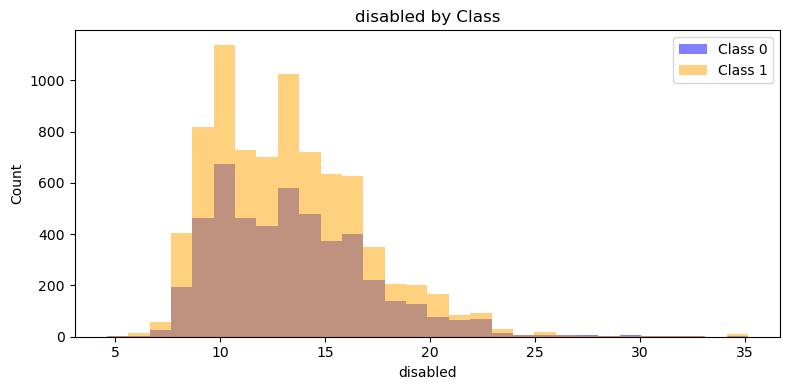

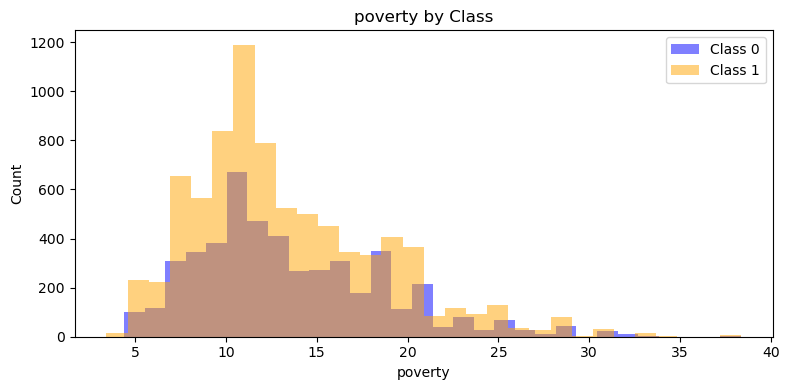

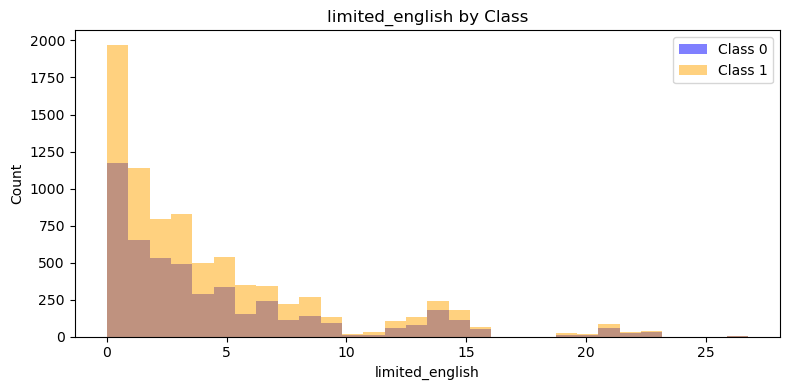

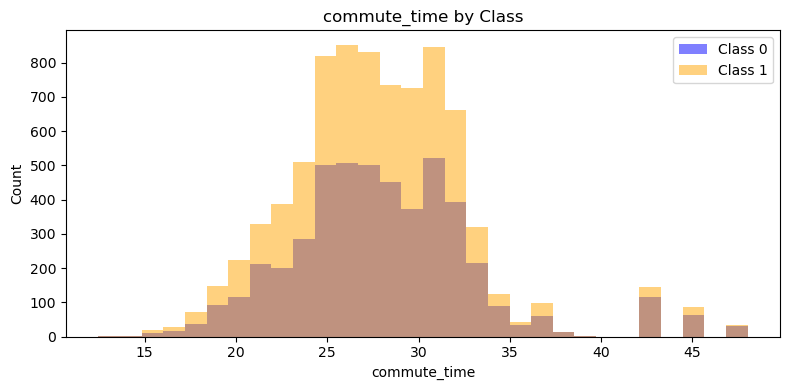

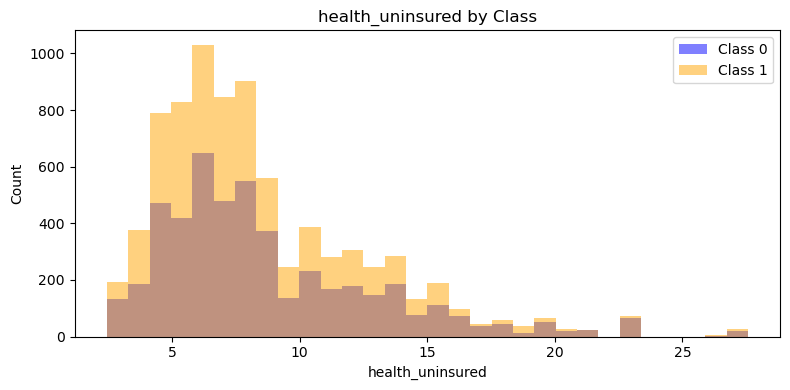

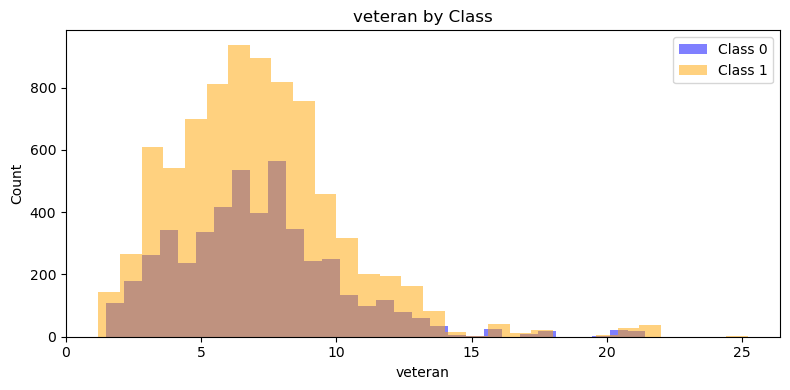

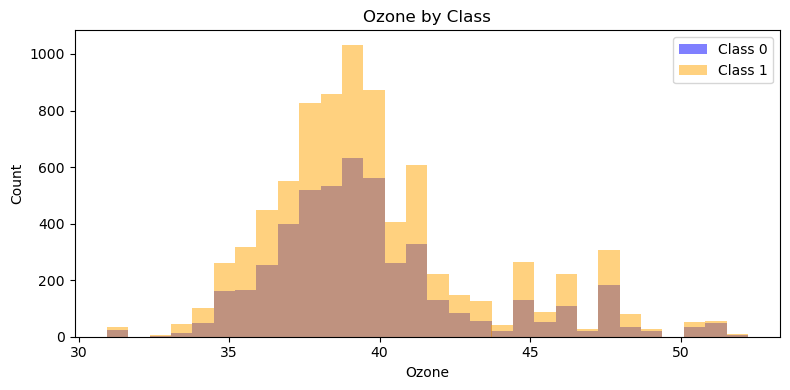

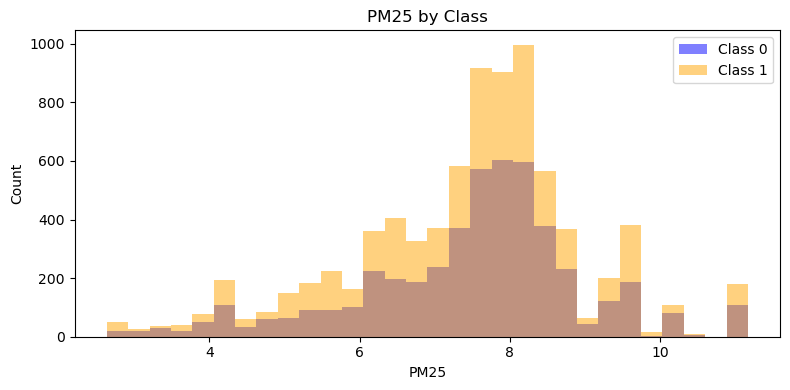

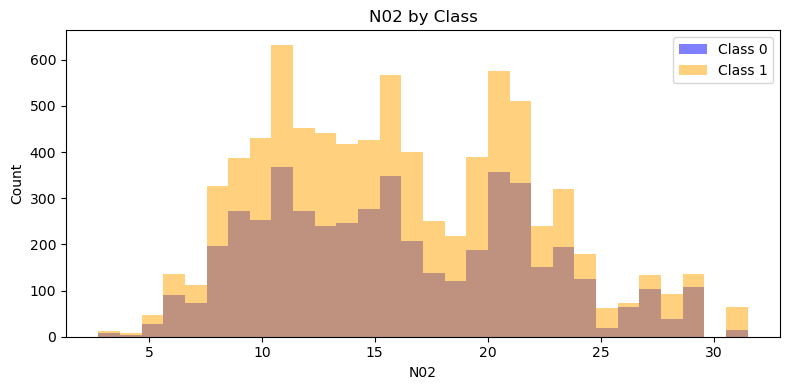

In [14]:
#comparing histogram every feature between the classes. 

numerical = train.select_dtypes(include=np.number).columns.tolist()
numerical.remove('DiagPeriodL90D')  # remove target

class0 = train[train['DiagPeriodL90D'] == 0]
class1 = train[train['DiagPeriodL90D'] == 1]

for col in numerical:
    plt.figure(figsize=(8, 4))
    plt.hist(class0[col].dropna(), bins=30, alpha=0.5, label='Class 0', color='blue')
    plt.hist(class1[col].dropna(), bins=30, alpha=0.5, label='Class 1', color='orange')
    plt.title(f'{col} by Class')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.legend()
    plt.tight_layout()
    plt.show()

In [15]:
#Categorical Features

categorical = train.select_dtypes(include='object').columns.tolist()
print(categorical)

for col in categorical:
    print(f"\n--- {col} ---")
    print(train.groupby(col)['DiagPeriodL90D'].value_counts(normalize=True).unstack())

['patient_race', 'payer_type', 'patient_state', 'patient_gender', 'breast_cancer_diagnosis_code', 'breast_cancer_diagnosis_desc', 'metastatic_cancer_diagnosis_code', 'metastatic_first_novel_treatment', 'metastatic_first_novel_treatment_type', 'Region', 'Division']

--- patient_race ---
DiagPeriodL90D         0         1
patient_race                      
Asian           0.369863  0.630137
Black           0.386364  0.613636
Hispanic        0.367913  0.632087
Other           0.373353  0.626647
White           0.340858  0.659142

--- payer_type ---
DiagPeriodL90D             0         1
payer_type                            
COMMERCIAL          0.401194  0.598806
MEDICAID            0.389646  0.610354
MEDICARE ADVANTAGE  0.357714  0.642286

--- patient_state ---
DiagPeriodL90D         0         1
patient_state                     
AK              0.500000  0.500000
AL              0.480000  0.520000
AR              0.301587  0.698413
AZ              0.379913  0.620087
CA              0.35

features look that most promising for ML task
breast_cancer_diagnosis_code — huge variation between classes (some codes are nearly 100% class 1, others nearly 100% class 0).
patient_state — some states like CO (82% class 1) and ND (83% class 1) vs NH (100% class 0) show strong variation. Useful.
metastatic_cancer_diagnosis_code — shows decent variation across codes.
payer_type — mild differences, less promising but still useful.
patient_race — very small differences between classes, probably not very useful.
patient_gender — only one value (F), so this column is useless.

features look that most promising for ML task 
- breast_cancer_diagnosis_code — huge variation between classes (some codes are nearly 100% class 1, others nearly 100% class 0). 
- patient_state — some states like CO (82% class 1) and ND (83% class 1) vs NH (100% class 0) show strong variation. Useful.
- metastatic_cancer_diagnosis_code — shows decent variation across codes. 
- payer_type — mild differences, less promising but still useful. 
- patient_race — very small differences between classes, probably not very useful. 
- patient_gender — only one value (F), so this column is useless.

###**Data Cleaning and Preparation**

In [16]:
print("Columns to consider dropping:")
print("- patient_gender (only one value):")
print(train['patient_gender'].unique())

# Check for any other columns with only 1 unique value
single_value_cols = [col for col in train.columns if train[col].nunique() == 1]
print("\nAll single-value columns:", single_value_cols)

Columns to consider dropping:
- patient_gender (only one value):
['F']

All single-value columns: ['patient_gender', 'metastatic_first_novel_treatment_type']


In [17]:
#Drop useless columns
train_clean = train.drop(columns=['patient_gender', 'metastatic_first_novel_treatment_type'])
test_clean = test.drop(columns=['patient_gender', 'metastatic_first_novel_treatment_type'])
print("Dropped single-value columns")

Dropped single-value columns


In [19]:
# Handle missing values

num_cols = train_clean.select_dtypes(include=np.number).columns.tolist()
num_cols_test = [col for col in num_cols if col in test_clean.columns]

train_clean[num_cols] = train_clean[num_cols].fillna(train_clean[num_cols].median())
test_clean[num_cols_test] = test_clean[num_cols_test].fillna(train_clean[num_cols_test].median())

cat_cols = train_clean.select_dtypes(include='object').columns
cat_cols_test = [col for col in cat_cols if col in test_clean.columns]

train_clean[cat_cols] = train_clean[cat_cols].fillna('Unknown')
test_clean[cat_cols_test] = test_clean[cat_cols_test].fillna('Unknown')

print("Missing values in train after cleaning:", train_clean.isnull().sum().sum())
print("Missing values in test after cleaning:", test_clean.isnull().sum().sum())

Missing values in train after cleaning: 0
Missing values in test after cleaning: 0


In [21]:
num_cols_test_no_target = [col for col in num_cols_test if col != 'DiagPeriodL90D']

test_clean[num_cols_test_no_target] = scaler.transform(test_clean[num_cols_test_no_target])

print("Rescaling done!")

Rescaling done!


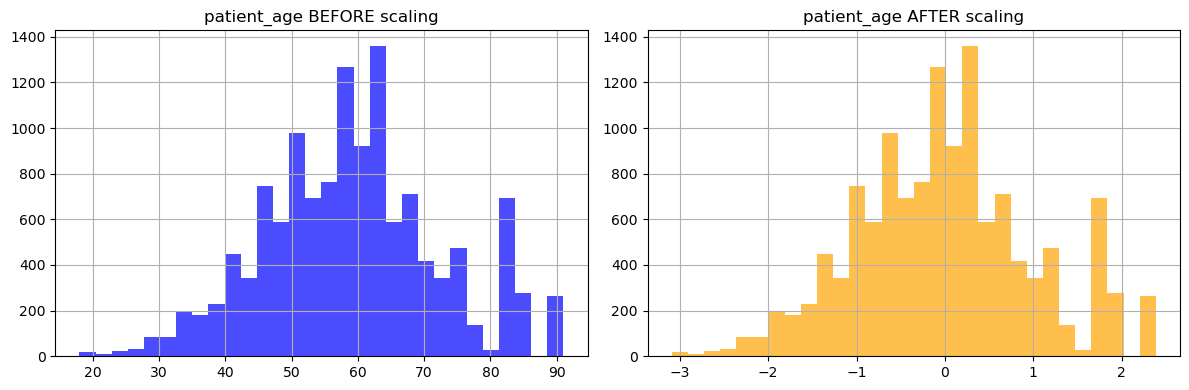

In [22]:
# Before vs After scaling visualization

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

train_before['patient_age'].hist(ax=axes[0], bins=30, color='blue', alpha=0.7)
axes[0].set_title('patient_age BEFORE scaling')

train_clean['patient_age'].hist(ax=axes[1], bins=30, color='orange', alpha=0.7)
axes[1].set_title('patient_age AFTER scaling')

plt.tight_layout()
plt.show()

In [23]:
# one-hot encode categorical features:
cat_cols = train_clean.select_dtypes(include='object').columns.tolist()

train_clean = pd.get_dummies(train_clean, columns=cat_cols)
test_clean = pd.get_dummies(test_clean, columns=[col for col in cat_cols if col in test_clean.columns])

train_clean, test_clean = train_clean.align(test_clean, join='left', axis=1, fill_value=0)

print("Train shape after encoding:", train_clean.shape)
print("Test shape after encoding:", test_clean.shape)

Train shape after encoding: (12906, 294)
Test shape after encoding: (5792, 294)


**###Machine Learning**

In [24]:
from sklearn.model_selection import train_test_split

# Dropping target and ID column
X = train_clean.drop(columns=['DiagPeriodL90D', 'patient_id'])
y = train_clean['DiagPeriodL90D']

# Splitting into train, validation, and test
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (9034, 292)
Validation size: (1936, 292)
Test size: (1936, 292)


In [25]:
# training the model

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report

# Train model
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Evaluate on validation set
y_pred = rf.predict(X_val)
y_pred_proba = rf.predict_proba(X_val)[:, 1]

print("Accuracy:", accuracy_score(y_val, y_pred))
print("ROC-AUC:", roc_auc_score(y_val, y_pred_proba))
print("\nClassification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.7753099173553719
ROC-AUC: 0.7729437280463943

Classification Report:
              precision    recall  f1-score   support

           0       0.79      0.58      0.67       753
           1       0.77      0.90      0.83      1183

    accuracy                           0.78      1936
   macro avg       0.78      0.74      0.75      1936
weighted avg       0.78      0.78      0.77      1936



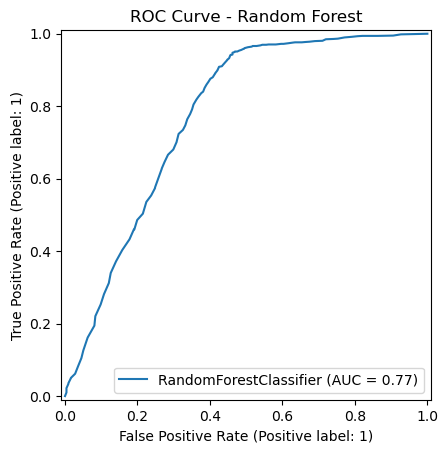

In [28]:
# ROC curve visualization

from sklearn.metrics import RocCurveDisplay

# ROC Curve
RocCurveDisplay.from_estimator(rf, X_val, y_val)
plt.title('ROC Curve - Random Forest')
plt.show()

In [29]:
# generate the submission

# Apply to test set
test_ids = test['patient_id']
X_kaggle = test_clean.drop(columns=['patient_id', 'DiagPeriodL90D'], errors='ignore')

y_kaggle_proba = rf.predict_proba(X_kaggle)[:, 1]

submission = pd.DataFrame({
    'patient_id': test_ids,
    'DiagPeriodL90D': y_kaggle_proba
})

submission.to_csv('submission.csv', index=False)
print("Submission file created!")
print(submission.head())

Submission file created!
   patient_id  DiagPeriodL90D
0      573710            0.91
1      593679            0.58
2      184532            0.84
3      447383            0.79
4      687972            0.83
